## **Customer Purchase Prediction (ML Project)**

The goal of this project is to build a machine learning model that can predict whether a user will make a purchase during a session on an e-commerce website.

This is a binary classification problem where the target variable indicates if a session ends in a purchase or not.

A key aspect of this project is that the model should be applicable in real-time. This means that predictions must be based only on features that are available while the user is actively browsing the website.

The purpose of this model is to help the business identify high-potential customers during their session and take actions such as:
- showing targeted offers
- recommending products
- improving user experience

In the following sections, we will explore the data, build different models, evaluate their performance, and analyze how the model can be used in practice.

---

## **Libraries and tools**

In this project, we use the following libraries:

- pandas and numpy for data manipulation
- matplotlib and seaborn for visualization
- scikit-learn for machine learning models and evaluation
- SMOTE for handling class imbalance

These tools will help us explore the data, train models, and evaluate their performance.

In [136]:
# Basic libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler


# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Evaluation
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, classification_report, confusion_matrix

# Hyperparameter tuning
from sklearn.model_selection import GridSearchCV

# imbalance
from imblearn.over_sampling import SMOTE

## **DATA UNDERSTANDING AND PREPARATION**

In [137]:
# load the shoppers dataset

shoppers_intention_df = pd.read_csv('data/project_data.csv')

shoppers_intention_df.head()   # Preview

,Unnamed: 0,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,NaN,1.0,1,Returning_Visitor,False,False
1,1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2.0,NaN,2,Returning_Visitor,False,False
2,2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1.0,NaN,3,Returning_Visitor,False,False
3,3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2.0,2.0,4,Returning_Visitor,False,False
4,4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3.0,1.0,4,Returning_Visitor,True,False


In [138]:
shoppers_intention_df.shape # Checking the shape of the dataset (rows, columns)

(12330, 19)

In [139]:
shoppers_intention_df.info() # Inspecting data types and missing values

<class 'pandas.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unnamed: 0               12330 non-null  int64  
 1   Administrative           12330 non-null  int64  
 2   Administrative_Duration  12330 non-null  float64
 3   Informational            12330 non-null  int64  
 4   Informational_Duration   12330 non-null  float64
 5   ProductRelated           12330 non-null  int64  
 6   ProductRelated_Duration  12330 non-null  float64
 7   BounceRates              12330 non-null  float64
 8   ExitRates                12330 non-null  float64
 9   PageValues               12330 non-null  float64
 10  SpecialDay               12207 non-null  float64
 11  Month                    12330 non-null  str    
 12  OperatingSystems         12330 non-null  int64  
 13  Browser                  12146 non-null  float64
 14  Region                   12084 no

- The dataset contains both numerical and categorical features.
- There are no obvious missing values based on the initial inspection.
- The target variable is "Revenue", which indicates whether the user made a purchase.

Some features represent user behavior during the session, such as:
- number of pages visited
- time spent on pages
- interaction with products

These types of features are especially important for real-time prediction, since they are available while the user is browsing.

---

## **EXPLORATORY DATA ANALYSIS (EDA)**

In [140]:
# Target Distribution Analysis

# Count how many sessions resulted in purchase vs no purchase
revenue_counts  = shoppers_intention_df["Revenue"].value_counts()
print("Purchase vs No Purchase (Count)",  revenue_counts)

print()

# Calculate proportions (percentage)
revenue_proportions = shoppers_intention_df["Revenue"].value_counts(normalize=True)
print("Purchase vs No Purchase (Proportion %)", revenue_proportions)

Purchase vs No Purchase (Count) Revenue
False    10303
True      1880
Name: count, dtype: int64

Purchase vs No Purchase (Proportion %) Revenue
False    0.845687
True     0.154313
Name: proportion, dtype: float64


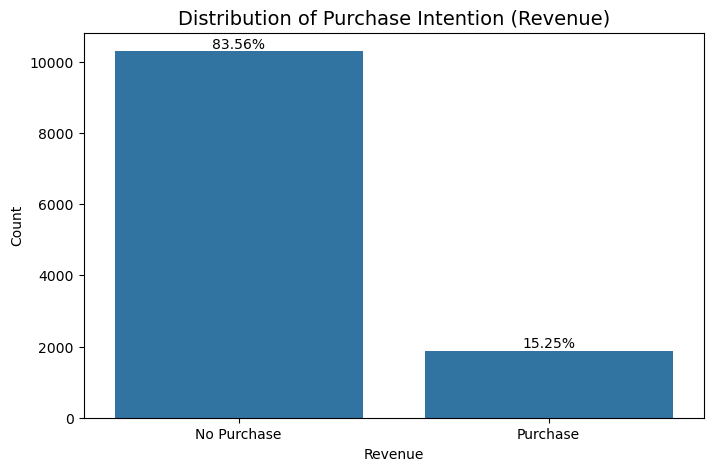

In [141]:
# Visualization of Target Distribution

plt.figure(figsize=(8,5))     # Create figure

ax = sns.countplot(x="Revenue", data=shoppers_intention_df)    # Create count plot

# Add title and labels
plt.title("Distribution of Purchase Intention (Revenue)", fontsize=14)
plt.xlabel("Revenue")
plt.ylabel("Count")

# Add custom labels to x-axis
ax.set_xticks([0, 1])
ax.set_xticklabels(["No Purchase", "Purchase"])

# Add percentage labels on top of bars
total = len(shoppers_intention_df)

for p in ax.patches:                          
    percentage = f"{100 * p.get_height() / total:.2f}%"
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(percentage, (x, y), ha='center', va='bottom')

plt.show()

### Class distribution

From the plot, we can clearly see that the dataset is imbalanced.

- Around 85% of sessions do NOT result in a purchase
- Only about 15% result in a purchase

This means that the model could easily achieve high accuracy by always predicting "No Purchase", which would not be useful.

Because of this imbalance:
- Accuracy alone is not a reliable metric
- We need to focus on metrics like precision, recall, and F1-score
- Techniques such as SMOTE or class weighting may be needed later

This is important because the goal is to correctly identify potential buyers, not just the majority class.

---

In [142]:
shoppers_intention_df["Revenue_label"] = shoppers_intention_df["Revenue"].map({False: "No Purchase", True: "Purchase"})

### Label transformation

We convert the "Revenue" variable into a more readable format:

- False: "No Purchase"
- True: "Purchase"

This makes the results easier to interpret in visualizations and analysis.

---

### Feature analysis with boxplots

To better understand how different features relate to purchase behavior, we use boxplots.

Boxplots allow us to compare the distribution of a feature between:
- users who made a purchase
- users who did not make a purchase

We also apply a log transformation to some features to reduce skewness and make patterns easier to observe.

In [143]:
# Function to plot boxplots

def plot_boxplot(df, column, log_transform=False):
    """
    This function plots a boxplot of a selected feature to see the difference
    between purchase and no purchase. It can also apply log transformation if needed.
    """
     
    # Apply log transformation if needed (to reduce skewness)
    if log_transform:
        col_name = f"log_{column}"
        df[col_name] = np.log1p(df[column])
    else:
        col_name = column
    
    # Create plot
    sns.boxplot(x="Revenue_label", y=col_name, data=df)
    
    plt.xlabel("Revenue")
    plt.ylabel(col_name)
    plt.title(f"{col_name} vs Purchase Behavior")
    
    plt.show()

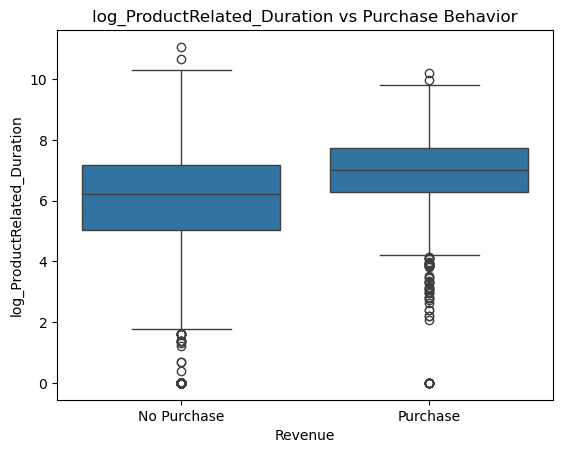

In [144]:
# Plot boxplot of ProductRelated_Duration (Apply log transformation to reduce skewness) to compare purchase vs no purchase

plot_boxplot(shoppers_intention_df, "ProductRelated_Duration", log_transform=True)

### Feature analysis: `ProductRelated_Duration`

After applying a log transformation, we observe that users who make a purchase tend to spend more time on product-related pages compared to those who do not purchase. This suggests that engagement with product content is an important factor in purchase decisions.

There is still overlap between the two groups, which means that this feature alone is not enough to perfectly separate buyers from non-buyers. From a real-time perspective, this feature is very useful, since it can be tracked while the user is browsing.

---

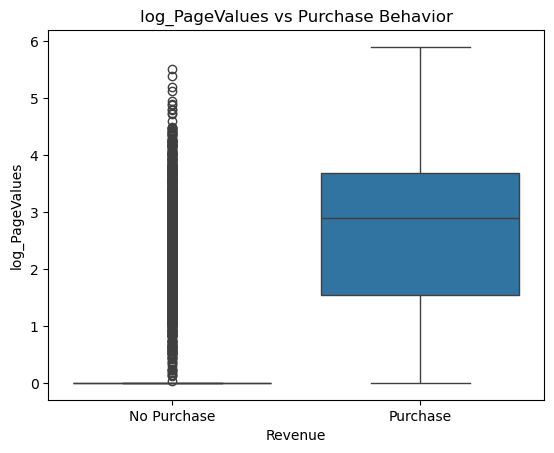

In [145]:
# Plot boxplot of PageValues (Apply log transformation to reduce skewness) to compare purchase vs no purchase

plot_boxplot(shoppers_intention_df, "PageValues", log_transform=True)

### Feature Analysis: `PageValues`

After applying a log transformation, we observe that users who make a purchase have higher PageValues compared to those who do not. There is a strong separation between the two groups, which indicates that this feature is highly informative.

This feature may introduce data leakage, since it can contain information that is only available at the end of the session or very close to the purchase decision. This will be considered later when selecting features for the final model, especially given the goal of making real-time predictions.

---

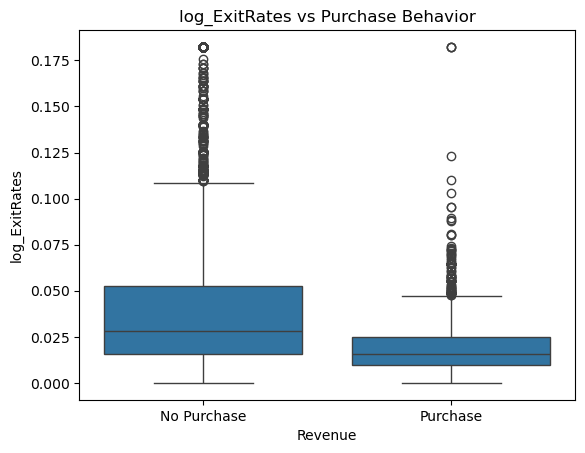

In [146]:
# Plot boxplot of ExitRates (Apply log transformation to reduce skewness) to compare purchase vs no purchase

plot_boxplot(shoppers_intention_df, "ExitRates", log_transform=True)

### Feature Analysis: `ExitRates`

The distribution shows that users who make a purchase tend to have lower exit rates compared to those who do not purchase. This suggests that users who leave the website more frequently are less likely to complete a purchase.

The overlap between the two groups is still significant, meaning that ExitRates alone is not a strong predictor. This feature may still contribute to the model, but likely in combination with other behavioral features.

---

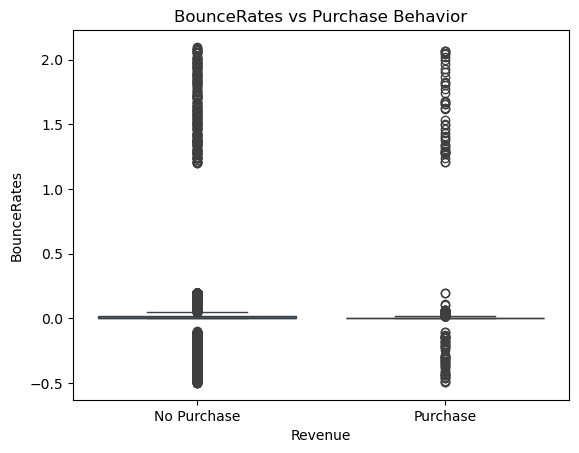

In [147]:
# Plot boxplot of BounceRates to compare purchase vs no purchase

plot_boxplot(shoppers_intention_df, "BounceRates")

### Feature analysis: `BounceRates`

The distribution of BounceRates does not show a clear separation between purchasing and non-purchasing users.

Additionally, we observe the presence of invalid values (negative values and values greater than 1), which indicates data quality issues. Since BounceRates should normally be within the range [0, 1], this suggests that the dataset contains inconsistencies.

### **Important Note :** 
Any data quality issues identified during EDA will be handled in the data preprocessing stage to ensure that the model is trained on reliable and consistent data.

---

In [148]:
# Keep original 'Revenue' for readability (EDA & plots)
# Create a new numeric version for correlation and ML models

shoppers_intention_df["Revenue_num"] = shoppers_intention_df["Revenue"].map({False: 0, True: 1})

# Check if mapping worked correctly
print(shoppers_intention_df[["Revenue", "Revenue_num"]].head())

print()

# Check distribution
print(shoppers_intention_df["Revenue_num"].value_counts())


  Revenue  Revenue_num
0   False          0.0
1   False          0.0
2   False          0.0
3   False          0.0
4   False          0.0

Revenue_num
0.0    10303
1.0     1880
Name: count, dtype: int64


In [149]:
# Create a copy to avoid modifying original dataset
df_corr = shoppers_intention_df.copy()

# Remove duplicated versions of features:
# We keep only one version (the log-transformed one)
# to avoid redundancy in correlation analysis

df_corr = df_corr.drop(columns=["Unnamed: 0", "PageValues", "ProductRelated_Duration", "ExitRates"])

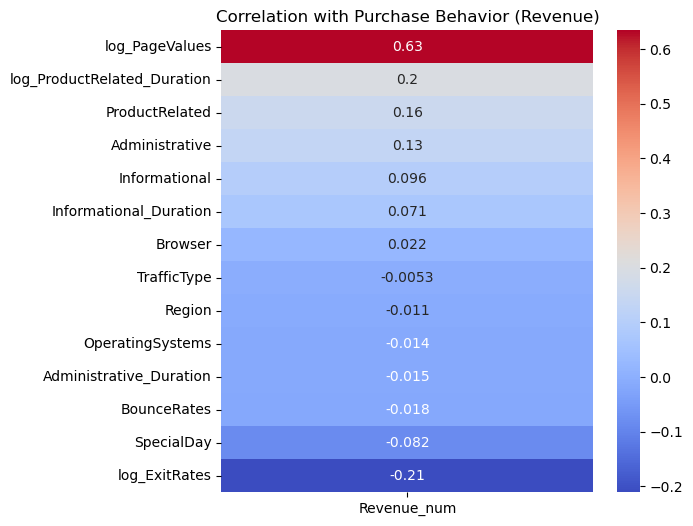

In [150]:
# Keep only numeric columns for correlation
numeric_df = df_corr.select_dtypes(include=["number"])

# Compute correlation of all features with target
corr_target = numeric_df.corr()["Revenue_num"].sort_values(ascending=False)

# Remove the target itself (correlation = 1, not useful)
corr_target = corr_target.drop("Revenue_num")

# Plot clean heatmap (only correlation with target)
plt.figure(figsize=(6,6))

sns.heatmap(corr_target.to_frame(), annot=True, cmap="coolwarm")
plt.title("Correlation with Purchase Behavior (Revenue)")

plt.show()

### Correlation interpretation

From the correlation analysis, we observe:

- log_PageValues shows the strongest positive correlation with the target variable
- ProductRelated and related engagement features also show moderate correlation
- Most other features have weak correlations with the target

This suggests that user engagement with product-related content is one of the most important factors influencing purchase behavior.

However, correlation alone is not enough to determine feature importance, and machine learning models will help capture more complex relationships.

Additionally, some highly correlated features (like PageValues) may not be suitable for real-time prediction and will be handled carefully.

---

## **INITIAL FEATURE HYPOTHESIS**

Based on the correlation analysis and EDA, the following features are expected to be among the most relevant:

- **log_PageValues**: Shows the strongest correlation with purchase behavior. However, this feature may introduce data leakage and will need to be evaluated carefully before being used in the model.
- **ProductRelated and log_ProductRelated_Duration**: Likely indicate how much the user interacts with product pages, suggesting higher engagement and purchase intent.
- **ExitRates**: Appears negatively correlated with the target, suggesting that users who leave quickly are less likely to purchase.
- **BounceRates**: May reflect low engagement and therefore a lower probability of conversion, although data quality issues were observed and will need to be addressed.

The following features are expected to have lower predictive value:

- **Browser, Region, TrafficType, and administrative-related features**, as they showed weak correlation with the target variable.

---

## **DATA VALIDATION**

In [ ]:
# Check shape of dataset 

shoppers_intention_df.shape

(12330, 24)

In [152]:
# Check unique values in target variable, this helps confirm it is a binary classification problem

shoppers_intention_df["Revenue"].unique()

array([False, nan, True], dtype=object)

In [153]:
# Check class distribution (important for imbalance)

shoppers_intention_df["Revenue"].value_counts()

Revenue
False    10303
True      1880
Name: count, dtype: int64

In [154]:
# Check distribution of Month, helps detect unexpected or invalid categories

print("Month distribution:")
print(shoppers_intention_df["Month"].value_counts())

Month distribution:
Month
May     3196
Nov     2998
Mar     1907
Dec     1727
Oct      549
Aug      433
Jul      432
Sep      359
June     288
Feb      184
Turc     168
Sept      89
Name: count, dtype: int64


In [155]:
# Check distribution of Weekend (should only contain True/False values)

print("Weekend distribution:")
print(shoppers_intention_df["Weekend"].value_counts())

Weekend distribution:
Weekend
False        9273
True         2868
Name:Zara     189
Name: count, dtype: int64


In [156]:
# Summary statistics of numeric features, helps identify outliers, skewness, and abnormal values

print("Numeric summary:")
shoppers_intention_df.describe(percentiles=[0.01, 0.99])

Numeric summary:


,Unnamed: 0,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType,log_ProductRelated_Duration,log_PageValues,log_ExitRates,Revenue_num
count,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12207.00000,12330.000000,12146.000000,12084.000000,12330.000000,12330.000000,12330.000000,12330.000000,12183.000000
mean,6164.500000,2.238200,1269.776004,0.503569,34.472398,31.731468,1194.746220,0.044239,0.043073,5.889258,0.06126,2.124006,2.360283,3.145647,4.069586,5.962529,0.624125,0.041151,0.154313
std,3559.508744,3.409269,34071.466930,1.270156,140.749294,44.475503,1913.669288,0.239735,0.048597,18.568437,0.19865,0.911325,1.722001,2.402440,4.025169,2.043091,1.267818,0.044487,0.361264
min,0.000000,-10.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.498680,0.000000,0.000000,0.00000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
1%,123.290000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,-0.370880,0.001250,0.000000,0.00000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.001249,0.000000
99%,12205.710000,14.000000,889.070000,6.000000,716.390000,221.000000,8701.142697,1.596644,0.200000,85.498490,1.00000,4.000000,10.000000,9.000000,20.000000,9.071325,4.460116,0.182322,1.000000
max,12329.000000,27.000000,989493.000000,24.000000,2549.375000,705.000000,63973.522230,2.098952,0.200000,361.763742,1.00000,8.000000,13.000000,9.000000,20.000000,11.066240,5.893752,0.182322,1.000000


In [157]:
# Check invalid values BounceRates (should be between 0 and 1)

invalid_bounce = shoppers_intention_df[(shoppers_intention_df["BounceRates"] < 0) | (shoppers_intention_df["BounceRates"] > 1)]

print("Invalid BounceRates:", len(invalid_bounce))

# Display some examples
invalid_bounce.head()

Invalid BounceRates: 609


,Unnamed: 0,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,...,Region,TrafficType,VisitorType,Weekend,Revenue,Revenue_label,log_ProductRelated_Duration,log_PageValues,log_ExitRates,Revenue_num
10,10,0,0.0,0,0.0,3,395.000000,1.767990,0.066667,0.0,...,3.0,3,Returning_Visitor,False,False,No Purchase,5.981414,0.0,0.064539,0.0
15,15,2,53.0,0,0.0,23,1668.285119,-0.395564,0.016313,0.0,...,9.0,3,Returning_Visitor,False,False,No Purchase,7.420151,0.0,0.016181,0.0
24,24,0,0.0,0,0.0,1,0.000000,-0.383570,0.200000,0.0,...,NaN,1,Returning_Visitor,True,False,No Purchase,0.000000,0.0,0.182322,0.0
42,42,0,0.0,0,0.0,15,310.166667,-0.409885,0.006667,0.0,...,4.0,4,Returning_Visitor,False,False,No Purchase,5.740329,0.0,0.006645,0.0
45,45,0,0.0,0,0.0,22,622.250000,-0.458046,0.006061,0.0,...,1.0,4,Returning_Visitor,False,False,No Purchase,6.434948,0.0,0.006042,0.0


In [158]:
# Check invalid values in Administrative (should be a count >= 0)

invalid_admin = shoppers_intention_df[shoppers_intention_df["Administrative"] < 0]

print("Invalid Administrative:", len(invalid_admin))

invalid_admin.head()

Invalid Administrative: 123


,Unnamed: 0,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,...,Region,TrafficType,VisitorType,Weekend,Revenue,Revenue_label,log_ProductRelated_Duration,log_PageValues,log_ExitRates,Revenue_num
143,143,-3,0.0,0,0.0,1,0.000000,0.2000,0.200000,0.0,...,2.0,3,Returning_Visitor,False,False,No Purchase,0.000000,0.0,0.182322,0.0
149,149,-8,0.0,0,0.0,11,316.666667,0.0000,0.027273,0.0,...,2.0,1,Returning_Visitor,False,False,No Purchase,5.761003,0.0,0.026907,0.0
150,150,-1,0.0,0,0.0,20,873.736508,0.0075,0.028167,0.0,...,1.0,1,Returning_Visitor,False,False,No Purchase,6.773923,0.0,0.027777,0.0
190,190,-7,0.0,0,0.0,2,0.000000,0.2000,0.200000,0.0,...,NaN,3,Returning_Visitor,False,False,No Purchase,0.000000,0.0,0.182322,0.0
201,201,-10,0.0,0,0.0,5,43.000000,0.0000,0.040000,0.0,...,1.0,9,Returning_Visitor,True,False,No Purchase,3.784190,0.0,0.039221,0.0


In [159]:
# Check invalid values in ProductRelated (should be >= 0)
invalid_product = shoppers_intention_df[shoppers_intention_df["ProductRelated"] < 0]
print(f"Total invalid in Product Related values: {len(invalid_product)}")

# Check invalid values in ExitRates (should be between 0 and 1)
invalid_exit = shoppers_intention_df[(shoppers_intention_df["ExitRates"] < 0) | (shoppers_intention_df["ExitRates"] > 1)]
print(f"Total invalid in Exit rates values: {len(invalid_exit)}")

# Quick invalid values in SpecialDay (should be between >= 0)
invalid_special = shoppers_intention_df[(shoppers_intention_df["SpecialDay"] < 0) | (shoppers_intention_df["SpecialDay"] > 1)]

print(f"Total invalid in Especial day values: {len(invalid_special)}")


Total invalid in Product Related values: 0
Total invalid in Exit rates values: 0
Total invalid in Especial day values: 0


In [160]:
# Check data types before cleaning to understand which variables need encoding

print("Columns before cleaning:")
shoppers_intention_df.dtypes

Columns before cleaning:


Unnamed: 0                       int64
Administrative                   int64
Administrative_Duration        float64
Informational                    int64
Informational_Duration         float64
ProductRelated                   int64
ProductRelated_Duration        float64
BounceRates                    float64
ExitRates                      float64
PageValues                     float64
SpecialDay                     float64
Month                              str
OperatingSystems                 int64
Browser                        float64
Region                         float64
TrafficType                      int64
VisitorType                        str
Weekend                            str
Revenue                         object
Revenue_label                      str
log_ProductRelated_Duration    float64
log_PageValues                 float64
log_ExitRates                  float64
Revenue_num                    float64
dtype: object

In [161]:
shoppers_intention_df.isnull().sum()  # Checking for missing values in the dataset

Unnamed: 0                       0
Administrative                   0
Administrative_Duration          0
Informational                    0
Informational_Duration           0
ProductRelated                   0
ProductRelated_Duration          0
BounceRates                      0
ExitRates                        0
PageValues                       0
SpecialDay                     123
Month                            0
OperatingSystems                 0
Browser                        184
Region                         246
TrafficType                      0
VisitorType                      0
Weekend                          0
Revenue                        147
Revenue_label                  147
log_ProductRelated_Duration      0
log_PageValues                   0
log_ExitRates                    0
Revenue_num                    147
dtype: int64

In [162]:
# Check duplicate rows
# Duplicate rows can bias the model

duplicated_clomuns = shoppers_intention_df.duplicated().sum()
print("Number of duplicates :", duplicated_clomuns)

Number of duplicates : 0


### Data validation summary

During the data validation step, several issues were identified in the dataset:

- Negative values in features that should only contain counts (e.g., Administrative)
- Values outside the expected range in BounceRates (should be between 0 and 1)
- Some inconsistencies in categorical variables such as Month and Weekend

At the same time, other features like ProductRelated, ExitRates, and SpecialDay appear to be within their expected ranges.

These findings indicate that the dataset contains some inconsistencies that need to be addressed before training any models.

---


## **DATA CLEANING**


In [163]:
# Clean Month feature

# Fix formatting inconsistency:
# "Sept" should be "Sep" (standard format used in dataset)
shoppers_intention_df["Month"] = shoppers_intention_df["Month"].replace({"Sept": "Sep"})

# Define valid months based on dataset documentation
valid_months = ["Feb","Mar","May","June","Jul","Aug","Sep","Oct","Nov","Dec"]

# Remove rows with invalid or unexpected month values (e.g., "Turc")
# These values do not belong to the dataset domain and may introduce noise
shoppers_intention_df = shoppers_intention_df[shoppers_intention_df["Month"].isin(valid_months)]

# Check distribution after cleaning
shoppers_intention_df["Month"].value_counts()

Month
May     3196
Nov     2998
Mar     1907
Dec     1727
Oct      549
Sep      448
Aug      433
Jul      432
June     288
Feb      184
Name: count, dtype: int64

In [164]:
sorted(shoppers_intention_df["Month"].unique())  # Check unique values after cleaning

['Aug', 'Dec', 'Feb', 'Jul', 'June', 'Mar', 'May', 'Nov', 'Oct', 'Sep']

The "Month" feature contained inconsistent categorical values.

Specifically:
- "Sept" was identified as a formatting inconsistency and was corrected to "Sep"
- "Turc" was identified as an invalid category with no correspondence in the original dataset and was removed

Only valid months present in the original dataset were retained to ensure data consistency and avoid introducing noise into the model.

---

In [165]:
# Cleaning Weekend feature

# Keep only valid values ("True", "False") and remove unexpected entries such as "NameZara"
shoppers_intention_df = shoppers_intention_df[shoppers_intention_df["Weekend"].isin(["True", "False"])]

# Convert from string to boolean, this ensures the variable has the correct binary format for modeling
shoppers_intention_df["Weekend"] = shoppers_intention_df["Weekend"].map({"True": True, "False": False})

In [166]:
shoppers_intention_df["Weekend"].value_counts()      # Verify distribution

Weekend
False    9150
True     2824
Name: count, dtype: int64

In [167]:
shoppers_intention_df["Weekend"].dtype                 # Check data type

dtype('bool')

The "Weekend" feature contained invalid categorical values.

Specifically:
- The value "Name:Zara" was identified as an invalid entry and was removed.

After filtering, the feature was converted from string format to boolean (True/False) to ensure compatibility with machine learning models and maintain consistency with its intended binary nature.

---

In [168]:
# Handle extreme values in Administrative_Duration

# Identify extreme values (very large durations)

invalid_administrative_duration = shoppers_intention_df[shoppers_intention_df["Administrative_Duration"] >= 4000]

print(f"Total invalid Administrative duration values: {len(invalid_administrative_duration)}")              # Print number of invalid rows

invalid_administrative_duration.head()             # Show first rows

Total invalid Administrative duration values: 15


,Unnamed: 0,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,...,Region,TrafficType,VisitorType,Weekend,Revenue,Revenue_label,log_ProductRelated_Duration,log_PageValues,log_ExitRates,Revenue_num
2560,2560,9,989493.0,4,154.0,154,8038.325302,0.007333,0.027963,0.0,...,1.0,5,Returning_Visitor,False,False,No Purchase,8.992100,0.0,0.027579,0.0
3757,3757,2,987522.0,1,201.0,14,1033.066667,0.012500,0.012292,0.0,...,6.0,3,Returning_Visitor,True,False,No Purchase,6.941255,0.0,0.012217,0.0
6160,6160,3,980612.0,0,0.0,24,755.000000,0.000000,0.007407,0.0,...,7.0,2,New_Visitor,True,False,No Purchase,6.628041,0.0,0.007380,0.0
6434,6434,0,971707.0,0,0.0,9,249.410000,0.022222,0.005128,0.0,...,1.0,4,Returning_Visitor,False,False,No Purchase,5.523100,0.0,0.005115,0.0
7109,7109,2,968066.0,0,0.0,45,580.935714,0.004444,0.005000,0.0,...,1.0,2,New_Visitor,False,False,No Purchase,6.366360,0.0,0.004988,0.0


In [169]:
# Remove extreme outliers to avoid distortion in the model (This values looks more like noise)

shoppers_intention_df = shoppers_intention_df[shoppers_intention_df["Administrative_Duration"] <= 4000]

# Analyze distribution without extreme value

shoppers_intention_df["Administrative_Duration"].describe()

count    11959.000000
mean        80.645974
std        176.378723
min          0.000000
25%          0.000000
50%          8.000000
75%         93.500000
max       3398.750000
Name: Administrative_Duration, dtype: float64

In [170]:
# Apply log transformation to reduce skewness. This helps compress large values and make distribution more stable

shoppers_intention_df["log_Administrative_Duration"] = np.log1p(shoppers_intention_df["Administrative_Duration"])

In [171]:
# Check distribution after transformation

shoppers_intention_df["log_Administrative_Duration"].describe()

count    11959.000000
mean         2.307230
std          2.364125
min          0.000000
25%          0.000000
50%          2.197225
75%          4.548600
max          8.131457
Name: log_Administrative_Duration, dtype: float64

In [172]:
# Clean BounceRates

# Filter invalid BounceRates values (should be between 0 and 1)
invalid_bounce = shoppers_intention_df[(shoppers_intention_df["BounceRates"] < 0) | (shoppers_intention_df["BounceRates"] > 1)]


print(f"Total invalid Bounce rates values: {len(invalid_bounce)}")     # Print number of invalid rows


invalid_bounce.head()           # Show first rows

Total invalid Bounce rates values: 592


,Unnamed: 0,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,...,TrafficType,VisitorType,Weekend,Revenue,Revenue_label,log_ProductRelated_Duration,log_PageValues,log_ExitRates,Revenue_num,log_Administrative_Duration
10,10,0,0.0,0,0.0,3,395.000000,1.767990,0.066667,0.0,...,3,Returning_Visitor,False,False,No Purchase,5.981414,0.0,0.064539,0.0,0.000000
15,15,2,53.0,0,0.0,23,1668.285119,-0.395564,0.016313,0.0,...,3,Returning_Visitor,False,False,No Purchase,7.420151,0.0,0.016181,0.0,3.988984
24,24,0,0.0,0,0.0,1,0.000000,-0.383570,0.200000,0.0,...,1,Returning_Visitor,True,False,No Purchase,0.000000,0.0,0.182322,0.0,0.000000
42,42,0,0.0,0,0.0,15,310.166667,-0.409885,0.006667,0.0,...,4,Returning_Visitor,False,False,No Purchase,5.740329,0.0,0.006645,0.0,0.000000
45,45,0,0.0,0,0.0,22,622.250000,-0.458046,0.006061,0.0,...,4,Returning_Visitor,False,False,No Purchase,6.434948,0.0,0.006042,0.0,0.000000


In [173]:
# Remove invalid rows (these values are not logically valid for this feature)

shoppers_intention_df = shoppers_intention_df[(shoppers_intention_df["BounceRates"] >= 0) & (shoppers_intention_df["BounceRates"] <= 1)]

In [174]:
# Verify that the feature now only contains valid values

shoppers_intention_df["BounceRates"].describe()

count    11367.000000
mean         0.021928
std          0.048063
min          0.000000
25%          0.000000
50%          0.003030
75%          0.016667
max          0.200000
Name: BounceRates, dtype: float64

In [175]:
# Check impact on target variable after cleaning. Important to ensure we did not distort the dataset balance

shoppers_intention_df["Revenue"].value_counts(normalize=True)

Revenue
False    0.845736
True     0.154264
Name: proportion, dtype: float64

### Numerical data cleaning summary

During the data cleaning process, some issues were found in the numerical features.

- In Administrative_Duration, there were some extremely large values that did not match the general distribution of the data. These values were handled to avoid affecting the model.

- In BounceRates, some values were outside the expected range (between 0 and 1), so those rows were removed.

The goal was to clean only clearly incorrect values while keeping most of the data unchanged. After this step, the dataset is more consistent.

---

In [176]:
# Check invalid values in Administrative

# Filter invalid Administrative values (negative values)
invalid_admin = shoppers_intention_df[shoppers_intention_df["Administrative"] < 0]


print(f"Total invalid Administrative values: {len(invalid_admin)}")                   # Print number of invalid rows


invalid_admin.head()      # Show first rows

Total invalid Administrative values: 115


,Unnamed: 0,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,...,TrafficType,VisitorType,Weekend,Revenue,Revenue_label,log_ProductRelated_Duration,log_PageValues,log_ExitRates,Revenue_num,log_Administrative_Duration
143,143,-3,0.0,0,0.0,1,0.000000,0.2000,0.200000,0.0,...,3,Returning_Visitor,False,False,No Purchase,0.000000,0.0,0.182322,0.0,0.0
149,149,-8,0.0,0,0.0,11,316.666667,0.0000,0.027273,0.0,...,1,Returning_Visitor,False,False,No Purchase,5.761003,0.0,0.026907,0.0,0.0
150,150,-1,0.0,0,0.0,20,873.736508,0.0075,0.028167,0.0,...,1,Returning_Visitor,False,False,No Purchase,6.773923,0.0,0.027777,0.0,0.0
190,190,-7,0.0,0,0.0,2,0.000000,0.2000,0.200000,0.0,...,3,Returning_Visitor,False,False,No Purchase,0.000000,0.0,0.182322,0.0,0.0
201,201,-10,0.0,0,0.0,5,43.000000,0.0000,0.040000,0.0,...,9,Returning_Visitor,True,False,No Purchase,3.784190,0.0,0.039221,0.0,0.0


In [177]:
# Check impact on target variable


# Check distribution of target within invalid rows. This helps ensure that removing them will not distort the dataset

invalid_admin["Revenue"].value_counts(normalize=True)

Revenue
False    0.868421
True     0.131579
Name: proportion, dtype: float64

In [178]:
# Compare with full dataset

shoppers_intention_df["Revenue"].value_counts(normalize=True)

Revenue
False    0.845736
True     0.154264
Name: proportion, dtype: float64

In [179]:
# Remove invalid Administrative values (negative counts are not possible)

shoppers_intention_df = shoppers_intention_df[shoppers_intention_df["Administrative"] >= 0]

In [180]:
# Verify that the feature now only contains valid values

shoppers_intention_df["Administrative"].describe()

count    11252.000000
mean         2.310967
std          3.312709
min          0.000000
25%          0.000000
50%          1.000000
75%          4.000000
max         27.000000
Name: Administrative, dtype: float64

Some negative values were found in the Administrative feature, which should only contain counts. Since negative values do not make sense here, those rows were removed.

Before removing them, the feature is more consistent and ready to be used in the model.

---

In [181]:
# Handle missing values on the target feature

shoppers_intention_df["Revenue"].value_counts()         # Check how many samples belong to each class before cleaning

Revenue
False    9402
True     1718
Name: count, dtype: int64

In [182]:
# Remove missing values in target

shoppers_intention_df = shoppers_intention_df.dropna(subset=["Revenue"])    # We cannot train a model without knowing the true outcome

In [183]:
# Convert target to boolean

shoppers_intention_df["Revenue"] = shoppers_intention_df["Revenue"].astype(bool)          # This makes it easier to work with for classification models

Some rows had missing values in the target variable (Revenue), so they were removed.

Since the target is what the model is trying to predict, rows without this value are not useful for training. Filling these values wouldn’t make sense, because it would be like guessing the result, which could affect the model.

Also, the target was converted to boolean (True/False) to make it easier to work with in the model.

---

In [184]:
# Handle missing values on others features

# Fill missing values in SpecialDay using the median
shoppers_intention_df["SpecialDay"] = shoppers_intention_df["SpecialDay"].fillna(shoppers_intention_df["SpecialDay"].median())

# Fill missing values in Browser using the most common value (mode)
shoppers_intention_df["Browser"] = shoppers_intention_df["Browser"].fillna(shoppers_intention_df["Browser"].mode()[0])

# Fill missing values in Region using the most common value (mode)
shoppers_intention_df["Region"] = shoppers_intention_df["Region"].fillna(shoppers_intention_df["Region"].mode()[0])

# Convert Browser and Region to integer format, these were stored as floats due to missing values
shoppers_intention_df["Browser"] = shoppers_intention_df["Browser"].astype(int)
shoppers_intention_df["Region"] = shoppers_intention_df["Region"].astype(int)

Missing values were found in some features and handled depending on the type of variable.

- For SpecialDay, the median was used since the data is not evenly distributed and this helps avoid extreme values affecting the result.

- For Browser and Region, the most common value (mode) was used, since these are categorical features.

The goal was to fill missing values in a simple way without changing the data too much. After this step, the dataset is complete and ready for modeling.

---

In [185]:
# Final checks after cleaning

shoppers_intention_df.isnull().sum()   # Check if there are still missing values in the dataset, everything expect to be 0 at this point

Unnamed: 0                     0
Administrative                 0
Administrative_Duration        0
Informational                  0
Informational_Duration         0
ProductRelated                 0
ProductRelated_Duration        0
BounceRates                    0
ExitRates                      0
PageValues                     0
SpecialDay                     0
Month                          0
OperatingSystems               0
Browser                        0
Region                         0
TrafficType                    0
VisitorType                    0
Weekend                        0
Revenue                        0
Revenue_label                  0
log_ProductRelated_Duration    0
log_PageValues                 0
log_ExitRates                  0
Revenue_num                    0
log_Administrative_Duration    0
dtype: int64

In [186]:
# Check data types

print("Columns after cleaning:")              # Print data types of each column
shoppers_intention_df.dtypes                  # This helps confirm that variables are in the correct format

Columns after cleaning:


Unnamed: 0                       int64
Administrative                   int64
Administrative_Duration        float64
Informational                    int64
Informational_Duration         float64
ProductRelated                   int64
ProductRelated_Duration        float64
BounceRates                    float64
ExitRates                      float64
PageValues                     float64
SpecialDay                     float64
Month                              str
OperatingSystems                 int64
Browser                          int64
Region                           int64
TrafficType                      int64
VisitorType                        str
Weekend                           bool
Revenue                           bool
Revenue_label                      str
log_ProductRelated_Duration    float64
log_PageValues                 float64
log_ExitRates                  float64
Revenue_num                    float64
log_Administrative_Duration    float64
dtype: object

In [187]:
shoppers_intention_df.shape  # Check shape after cleaning

(11120, 25)

After cleaning the dataset, a few final checks were done to make sure everything looks correct.

- Missing values were removed or handled
- Invalid values were cleaned
- Data types were adjusted where needed

The dataset now contains 11120 rows and 25 columns after cleaning. Some rows were removed during the process, but most of the data was kept.

No major issues were found after these checks, so the data is ready to move to the next step.

---

## **FEATURE SELECTION**

In [188]:
# columns to remove:
# unnamed: index column, not useful
# Revenue_label / Revenue_num: alternative versions of the target (avoid duplication and data leakage)
# ProductRelated_Duration / Administrative_Duration: replaced by log versions
# PageValues: not available in real-time (data leakage)
# log_PageValues: not available in real-time (data leakage)
# log_ExitRates: keeping only one version of the feature

columns_to_drop = [
    "Unnamed: 0",
    "Revenue_label",
    "Revenue_num",
    "ProductRelated_Duration",
    "PageValues",
    "log_PageValues",
    "log_ExitRates",
    "Administrative_Duration"
]

# drop selected columns
shoppers_intention_df = shoppers_intention_df.drop(columns=columns_to_drop)

shoppers_intention_df.columns                # check remaining columns

Index(['Administrative', 'Informational', 'Informational_Duration',
       'ProductRelated', 'BounceRates', 'ExitRates', 'SpecialDay', 'Month',
       'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType',
       'Weekend', 'Revenue', 'log_ProductRelated_Duration',
       'log_Administrative_Duration'],
      dtype='str')

In [189]:
shoppers_intention_df.shape           # Check shape after feature selection

(11120, 17)

To prepare the data for modeling, only the features that would realistically be available during a user session were kept.

- Some columns were removed because they could introduce data leakage, especially PageValues, which is calculated after a purchase and would not be available in real time.

- Other columns were removed to avoid duplication, keeping only one version of transformed variables (such as log features).

After this step, the dataset is simpler, more consistent, and better aligned with a real-world prediction scenario.

---

## **FEATURE AND TARGET DEFINITION**

In [190]:
# Define features and target

X = shoppers_intention_df.drop(columns=["Revenue"])    # X contains all input variables (features)
y = shoppers_intention_df["Revenue"]                   # y contains the target variable to predict

# Quick check shapes
print(X.shape)
print(y.shape)

(11120, 16)
(11120,)


In [191]:
X.columns  # Check feature names to confirm which variables will be used in the model

Index(['Administrative', 'Informational', 'Informational_Duration',
       'ProductRelated', 'BounceRates', 'ExitRates', 'SpecialDay', 'Month',
       'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType',
       'Weekend', 'log_ProductRelated_Duration',
       'log_Administrative_Duration'],
      dtype='str')

## **TRAIN / VALIDATION / TEST SPLIT**

In [192]:
# First split: separate test set (20%)

test_size = 0.2      # 25% of train_val = 20% of total

X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=test_size, random_state=42, stratify=y)  # stratify=y keep class distribution consistent

# Check shapes
print("Train/Validation:", X_train_val.shape)
print("Test:", X_test.shape)

Train/Validation: (8896, 16)
Test: (2224, 16)


In [193]:
# Split train into train and validation

validation_size = 0.25

X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=validation_size, random_state=41, stratify=y_train_val)  #  stratify keep class distribution consistent

# Check shapes
print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (6672, 16)
Validation: (2224, 16)
Test: (2224, 16)


The dataset was split into three parts:

- Training set: used to train the model  
- Validation set: used to tune and compare models  
- Test set: used only at the end for final evaluation  

A stratified split was used to keep the class distribution consistent across all sets, since the dataset is imbalanced.

This ensures that all subsets represent the original data properly.

## **ENCODING**

In [194]:
# Encoding categorical variables

categorical_cols = ["Month", "VisitorType"]           # Define categorical and numerical columns
numeric_cols = X_train.columns.drop(categorical_cols)

In [195]:
# Initialize OneHotEncoder
# drop="first" avoids multicollinearity and handle_unknown="ignore" prevents errors if new categories appear

encoder = OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False)

In [196]:
# Fit encoder ONLY on training data, this avoids data leakage

X_train_cat = encoder.fit_transform(X_train[categorical_cols])

In [197]:
# Apply same transformation to validation and test sets

X_val_cat = encoder.transform(X_val[categorical_cols])
X_test_cat = encoder.transform(X_test[categorical_cols])

In [198]:
# get names of encoded columns
encoded_cols = encoder.get_feature_names_out(categorical_cols)

# convert encoded arrays into DataFrames
X_train_cat_df = pd.DataFrame(X_train_cat, columns=encoded_cols, index=X_train.index)
X_val_cat_df = pd.DataFrame(X_val_cat, columns=encoded_cols, index=X_val.index)
X_test_cat_df = pd.DataFrame(X_test_cat, columns=encoded_cols, index=X_test.index)

# combine numerical and encoded categorical features, drop original categorical columns and replace with encoded ones
X_train = pd.concat([X_train[numeric_cols], X_train_cat_df], axis=1)
X_val = pd.concat([X_val[numeric_cols], X_val_cat_df], axis=1)
X_test = pd.concat([X_test[numeric_cols], X_test_cat_df], axis=1)

In [199]:
# Check final shapes
print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (6672, 25)
Validation: (2224, 25)
Test: (2224, 25)


Categorical variables were encoded using OneHotEncoding.

- The encoder was fitted only on the training data and then applied to the validation and test sets. This was done to avoid data leakage.

- The option handle_unknown="ignore" was used to make sure the model can handle new categories that were not seen during training.

After encoding, the categorical variables were replaced with their encoded versions and combined with the numerical features.

---

## **SCALING** 

In [200]:
# Initialize scaler
scaler = StandardScaler()

# fit scaler ONLY on training data, this avoids data leakage
X_train_scaled = scaler.fit_transform(X_train)

# Apply the same transformation to validation and test sets
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

Feature scaling was applied using StandardScaler. 

- The scaler was fitted only on the training data and then applied to the validation and test sets to avoid data leakage.

- Scaling is mainly needed for models like linear models and KNN, since they are sensitive to the scale of the features. Tree-based models like Random Forest do not require scaling.

---

## **LOGISTIC REGRESSION MODEL (with class balancing)**

Dataset balanced with the command`class_weight="balanced"`

In [201]:
# Logistic Regression (Baseline Model)

# Initialize model with class balancing to handle imbalanced dataset
logistic_model = LogisticRegression(class_weight="balanced")

# Train model using scaled features
logistic_model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [202]:
# Generate predictions on validation set

y_val_pred_log = logistic_model.predict(X_val_scaled)   

In [203]:
# Evaluate model performance

print(classification_report(y_val, y_val_pred_log))  # Print classification metrics (precision, recall, f1-score)

              precision    recall  f1-score   support

       False       0.93      0.62      0.75      1881
        True       0.27      0.76      0.39       343

    accuracy                           0.64      2224
   macro avg       0.60      0.69      0.57      2224
weighted avg       0.83      0.64      0.69      2224



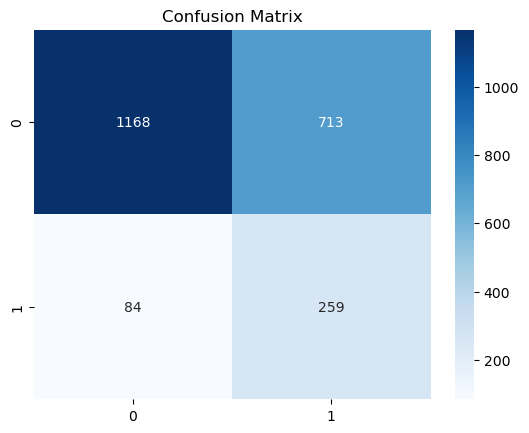

In [204]:
# Confusion matrix to visualize errors

cm = confusion_matrix(y_val, y_val_pred_log)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

### Logistic regression results

The model was able to detect most of the users who made a purchase, as shown by the high recall for the positive class.

The precision is quite low, which means that many users were incorrectly predicted as buyers when they were not., tis shows that the model is biased towards predicting the positive class, likely due to the use of class_weight="balanced".

From a real-work perspective, this could be useful if the goal is to not miss potential buyers, but it may also lead to unnecessary actions being taken on users who are unlikely to convert.

This model provides a good starting point, but there is room for improvement, especially in balancing precision and recall.

---

### **THRESHOLD TUNING TO LOGISTIC REGRESSION**

In [205]:
# Get predicted probabilities for positive class
y_val_prob_log = logistic_model.predict_proba(X_val_scaled)[:, 1]

# Define custom threshold (more strict than default 0.5)
threshold = 0.6

# Apply threshold to convert probabilities into class predictions
y_val_pred_custom_log = (y_val_prob_log >= threshold).astype(int)

In [206]:
# Evaluate model performance

print(classification_report(y_val, y_val_pred_custom_log))                 # Print classification metrics (precision, recall, f1-score)

              precision    recall  f1-score   support

       False       0.91      0.74      0.82      1881
        True       0.29      0.59      0.39       343

    accuracy                           0.72      2224
   macro avg       0.60      0.67      0.61      2224
weighted avg       0.81      0.72      0.75      2224



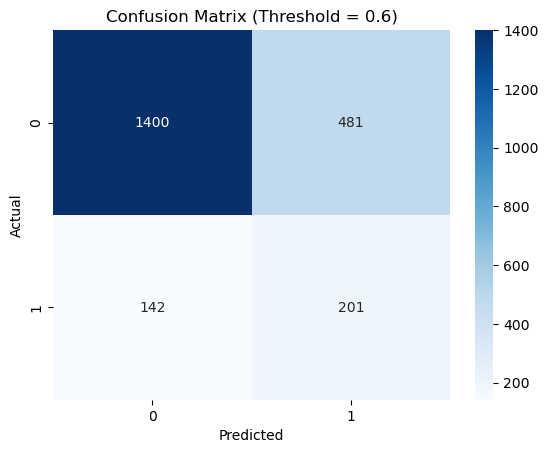

In [207]:
# Confusion matrix with custom threshold

cm_custom = confusion_matrix(y_val, y_val_pred_custom_log)

# Visualize confusion matrix
sns.heatmap(cm_custom, annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion Matrix (Threshold = {threshold})")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Logistic regression with threshold tuning results

The model was first evaluated using the default threshold of 0.5, then, a higher threshold of 0.6 was applied to make the model more conservative.

After increasing the threshold, the number of false positives decreased, which means fewer users were incorrectly predicted as buyers, this also reduced the recall, meaning that some real buyers were missed.

This shows the trade-off between precision and recall. A higher threshold makes the model stricter, while a lower threshold makes it more flexible. The choice of threshold depends on the business goal. In this case, increasing the threshold helps reduce unnecessary actions, but at the cost of missing some potential buyers.

---

### **ERROR ANALYSIS TO THRESHOLD TUNING LOGISTIC REGRESSION**

In [208]:
# Create a copy of validation set to avoid modifying original data
X_val_analysis_log = X_val.copy()

# Add actual and predicted values
X_val_analysis_log["actual"] = y_val
X_val_analysis_log["pred"] = y_val_pred_custom_log   # using threshold model

# False Positives: predicted purchase but actually no purchase
false_positives = X_val_analysis_log[(X_val_analysis_log["actual"] == 0) & (X_val_analysis_log["pred"] == 1)]

# False Negatives: predicted no purchase but actually purchase
false_negatives = X_val_analysis_log[(X_val_analysis_log["actual"] == 1) & (X_val_analysis_log["pred"] == 0)]

In [209]:
# Print number of errors

print("False Positives:", len(false_positives))
print("False Negatives:", len(false_negatives))

False Positives: 481
False Negatives: 142


In [210]:
false_positives.head()

,Administrative,Informational,Informational_Duration,ProductRelated,BounceRates,ExitRates,SpecialDay,OperatingSystems,Browser,Region,...,Month_June,Month_Mar,Month_May,Month_Nov,Month_Oct,Month_Sep,VisitorType_Other,VisitorType_Returning_Visitor,actual,pred
350,2,0,0.0,15,0.0000,0.006250,0.0,2,2,1,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,False,1
11561,5,1,0.0,117,0.0129,0.020948,0.0,3,2,1,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,False,1
9872,7,0,0.0,16,0.0000,0.009524,0.0,2,6,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,False,1
5794,0,0,0.0,3,0.0000,0.033333,0.0,1,2,1,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,False,1
5974,1,0,0.0,40,0.0000,0.012358,0.0,2,10,2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,False,1


In [211]:
false_negatives.head()

,Administrative,Informational,Informational_Duration,ProductRelated,BounceRates,ExitRates,SpecialDay,OperatingSystems,Browser,Region,...,Month_June,Month_Mar,Month_May,Month_Nov,Month_Oct,Month_Sep,VisitorType_Other,VisitorType_Returning_Visitor,actual,pred
8268,0,0,0.0,14,0.014286,0.042857,0.0,2,2,4,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,True,0
2070,5,1,415.0,20,0.000000,0.010000,0.0,1,1,3,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,True,0
2990,0,0,0.0,28,0.007143,0.032381,0.0,2,4,3,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,True,0
11120,5,2,349.0,33,0.012821,0.044786,0.0,2,2,7,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,True,0
1161,1,0,0.0,16,0.022222,0.033333,0.0,3,2,4,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,True,0


In [212]:
# Analyze which traffic types are most common in false positives to understand where the model is over-predicting purchases

false_positives["TrafficType"].value_counts()  

TrafficType
2     237
1      59
3      53
4      32
10     16
5      16
11     15
8      15
13     13
20     11
6       9
9       2
15      2
7       1
Name: count, dtype: int64

In [213]:
false_negatives.columns  # Check all available columns in false negatives

Index(['Administrative', 'Informational', 'Informational_Duration',
       'ProductRelated', 'BounceRates', 'ExitRates', 'SpecialDay',
       'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'Weekend',
       'log_ProductRelated_Duration', 'log_Administrative_Duration',
       'Month_Dec', 'Month_Feb', 'Month_Jul', 'Month_June', 'Month_Mar',
       'Month_May', 'Month_Nov', 'Month_Oct', 'Month_Sep', 'VisitorType_Other',
       'VisitorType_Returning_Visitor', 'actual', 'pred'],
      dtype='str')

In [214]:
# Analyze distribution of months in false negatives to identify if the model struggles during specific periods

false_negatives.filter(like="Month").sum().sort_values(ascending=False)

Month_May     42.0
Month_Nov     35.0
Month_Mar     25.0
Month_Dec     19.0
Month_Oct      8.0
Month_Jul      7.0
Month_June     3.0
Month_Sep      1.0
Month_Feb      0.0
dtype: float64

In [215]:
# Analyze visitor type in false negatives to check if returning or new users are harder to predict 
false_negatives.filter(like="VisitorType").sum()

VisitorType_Other                  0.0
VisitorType_Returning_Visitor    129.0
dtype: float64

In [216]:
# Analyze ProductRelated feature for false negatives

false_negatives["ProductRelated"].describe()

count    142.000000
mean      29.091549
std       28.023522
min        1.000000
25%       10.000000
50%       19.000000
75%       37.750000
max      171.000000
Name: ProductRelated, dtype: float64

In [217]:
# Calculate error rates, this gives a better idea of how frequent each type of error is

false_positive_rate = false_positives.shape[0] / X_val.shape[0]
false_negative_rate = false_negatives.shape[0] / X_val.shape[0]

print(false_positive_rate, false_negative_rate)

0.21627697841726617 0.06384892086330936


Looking at the errors, the model tends to make mistakes in specific situations.

- There are many false positives, meaning that the model predicts purchases for users who actually do not buy. This could lead to unnecessary actions being taken.

- There are also false negatives, where real buyers are missed. This is important because these are potential customers that the model fails to identify.

From the analysis, it seems that errors are more frequent in certain traffic types and months, suggesting that user behavior is not being fully captured by the model. This indicates that the model struggles to understand more complex patterns related to when and how users interact with the website.

Even though the overall performance is acceptable, this analysis shows that there is still room for improvement, especially in capturing more detailed user behavior.

---


## **RANDOM FOREST CLASSIFIER MODEL (with class balancing)**

Dataset balanced with the command `class_weight="balanced"`

In [218]:
# Baseline Random Forest
#  using class_weight helps handle imbalanced data (more importance to minority class)

randomf_model = RandomForestClassifier(
    n_estimators=100,        # number of trees
    max_depth=None,          # trees grow fully (can capture complex patterns but risk overfitting)
    class_weight="balanced", # adjusts to handle class imbalance
    random_state=42
)

randomf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [219]:
# Make predictions on validation set
y_val_pred_rf_base = randomf_model.predict(X_val)

In [220]:
# Evaluate model performance

print(classification_report(y_val, y_val_pred_rf_base))            # Print classification metrics (precision, recall, f1-score)

              precision    recall  f1-score   support

       False       0.85      0.98      0.91      1881
        True       0.37      0.05      0.09       343

    accuracy                           0.84      2224
   macro avg       0.61      0.52      0.50      2224
weighted avg       0.78      0.84      0.79      2224



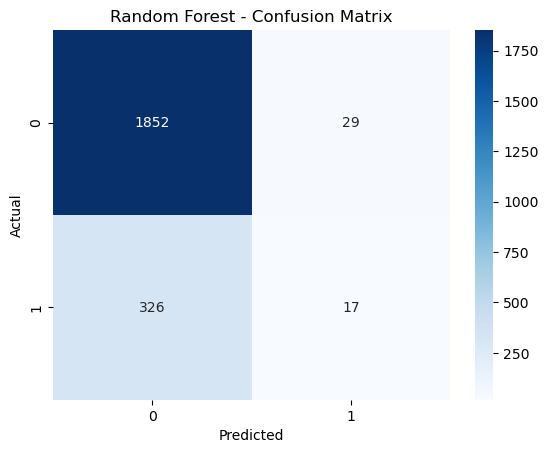

In [221]:
# Confusion matrix for errors

cm = confusion_matrix(y_val, y_val_pred_rf_base)

# Visualize confusion matrix
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Random Forest model results

The Random Forest model achieves high overall accuracy, but this is misleading. It performs very well in predicting non-purchasing users, but it fails to correctly identify users who actually make a purchase.

The recall for the positive class is extremely low, which means that most real buyers are being missed by the model. This suggests that the model is heavily biased toward the majority class (non-buyers) and is not effectively learning the patterns associated with purchasing behavior.

In practice, this would be a serious issue, since missing real buyers could lead to lost opportunities.

---

### **RANDOM FOREST CLASSIFIER MODEL (SMOTE + GRID SEARCH)**

In [222]:
# Apply SMOTE to balance the training data to creates synthetic samples for the minority class (buyers)

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [223]:
rf_model = RandomForestClassifier(random_state=42)       # Define Random Forest model


# Define hyperparameter grid for tuning
# Trying different combinations to improve model performance
param_grid = {
    "n_estimators": [100, 200],           # number of trees
    "max_depth": [5, 10, None],           # tree depth
    "min_samples_split": [2, 5],          # minimum samples to split a node
    "min_samples_leaf": [1, 2]            # minimum samples in a leaf
}


# Perform Grid Search with cross-validation, using recall as scoring to detect buyers
grid_search_rf = GridSearchCV(
    rf_model,
    param_grid,
    cv=3,                           # 3-fold cross-validation
    scoring="recall",               # focus on recall for positive class
    n_jobs=-1,                      # use all cores
    verbose=2
)

# Train model on SMOTE data
grid_search_rf.fit(X_train_smote, y_train_smote)

Fitting 3 folds for each of 24 candidates, totalling 72 fits


,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'max_depth': [5, 10, ...], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], 'n_estimators': [100, 200]}"
,scoring,'recall'
,n_jobs,-1
,refit,True
,cv,3
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,200


In [224]:
# Get the best model found during tuning
best_rf = grid_search_rf.best_estimator_

# Make predictions on validation set
y_val_pred_rf = best_rf.predict(X_val)

In [225]:
# Evaluate model performance

print(classification_report(y_val, y_val_pred_rf))                # Print classification metrics (precision, recall, f1-score)         

              precision    recall  f1-score   support

       False       0.87      0.93      0.90      1881
        True       0.38      0.23      0.28       343

    accuracy                           0.82      2224
   macro avg       0.62      0.58      0.59      2224
weighted avg       0.79      0.82      0.80      2224



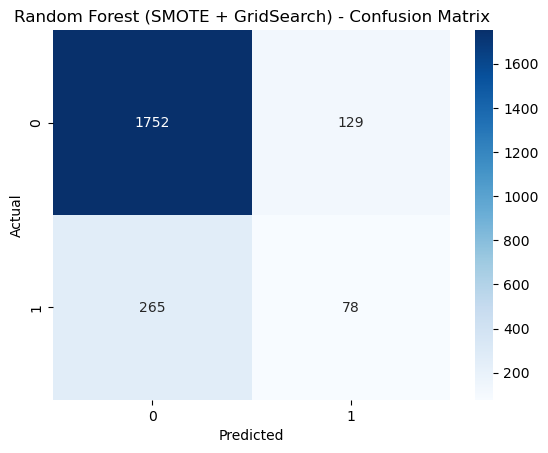

In [226]:
# Confusion matrix to visualize errors

cm_rf = confusion_matrix(y_val, y_val_pred_rf)

# Visualize confusion matrix
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Blues")
plt.title("Random Forest (SMOTE + GridSearch) - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Random Forest model (SMOTE + GridSearch) with threshold tuning results

After applying SMOTE and tuning the model with GridSearch, the Random Forest improved compared to the Random Forest baseline.

The model is now able to detect more real buyers, which is reflected in the increase in recall for the positive class, the improvement is still limited, and the model continues to miss a significant number of actual purchases.

This means that even though balancing the data helped, the model is still not capturing the patterns of buying behavior very well. This approach improved the model, but it is still not strong enough for a real-world use case where detecting buyers is important.

---

### **THRESHOLD TUNING TO RANDOM FOREST CLASSIFIER MODEL (SMOTE + GRID SEARCH)**

In [227]:
# Set a custom threshold (lower than default 0.5)
# Lower threshold = model predicts more positives (more buyers)

threshold = 0.3   

# Get predicted probabilities for the positive class (buyers)
y_val_proba_rf = best_rf.predict_proba(X_val)[:, 1]

# Convert probabilities into class predictions using custom threshold
y_val_pred_custom_rf = (y_val_proba_rf >= threshold).astype(int)

In [228]:
# Evaluate performance with the new threshold

print(classification_report(y_val, y_val_pred_custom_rf))        # Print classification metrics (precision, recall, f1-score)         

              precision    recall  f1-score   support

       False       0.91      0.76      0.83      1881
        True       0.31      0.57      0.40       343

    accuracy                           0.73      2224
   macro avg       0.61      0.67      0.61      2224
weighted avg       0.81      0.73      0.76      2224



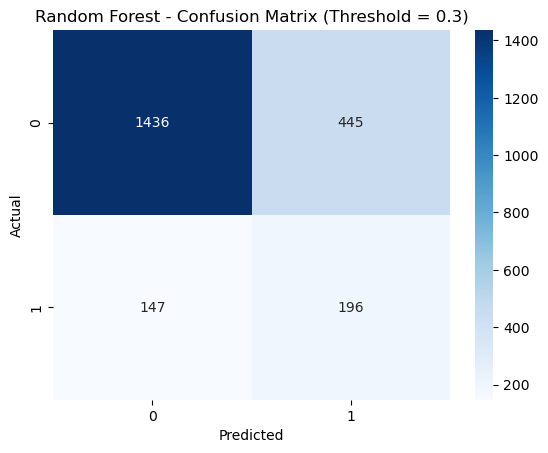

In [229]:
# Confusion matrix with custom threshold

cm_custom_rf = confusion_matrix(y_val, y_val_pred_custom_rf)

# Visualize confusion matrix
sns.heatmap(cm_custom_rf, annot=True, fmt="d", cmap="Blues")
plt.title(f"Random Forest - Confusion Matrix (Threshold = {threshold})")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Random Forest model (SMOTE + GridSearch)  results

After lowering the threshold to 0.3, the model is able to detect more real buyers.

The recall increased significantly, which means fewer actual customers are being missed. This comes at the cost of lower precision, meaning the model now predicts more purchases that do not actually happen.

In this case, the trade-off can be acceptable, since missing potential buyers could be more expensive than targeting users who might not convert. Adjusting the threshold helped improve the model in a more practical way.

---

### **ERROR ANALYSIS TO THRESHOLD TUNING RANDOM FOREST CLASSIFIER MODEL (SMOTE + GRID SEARCH)**

In [230]:
# Copy validation set to analyze errors without modifying original data
X_val_analysis_rf = X_val.copy()

# Add actual and predicted values
X_val_analysis_rf["actual"] = y_val
X_val_analysis_rf["pred"] = y_val_pred_custom_rf

In [231]:
# False Positives: predicted purchase but actually no purchase
false_positives_rf = X_val_analysis_rf[(X_val_analysis_rf["actual"] == 0) & (X_val_analysis_rf["pred"] == 1)]

# False Negatives: real purchase but model missed it
false_negatives_rf = X_val_analysis_rf[(X_val_analysis_rf["actual"] == 1) & (X_val_analysis_rf["pred"] == 0)]

In [232]:
# Print number of errors

print("False Positives RF:", len(false_positives_rf))
print("False Negatives RF:", len(false_negatives_rf))

False Positives RF: 445
False Negatives RF: 147


In [233]:
# Summary statistics of false negatives (real buyers missed by the model) to understand how these users behave on average
false_negatives.describe()

,Administrative,Informational,Informational_Duration,ProductRelated,BounceRates,ExitRates,SpecialDay,OperatingSystems,Browser,Region,...,Month_Jul,Month_June,Month_Mar,Month_May,Month_Nov,Month_Oct,Month_Sep,VisitorType_Other,VisitorType_Returning_Visitor,pred
count,142.000000,142.000000,142.000000,142.000000,142.000000,142.000000,142.000000,142.000000,142.000000,142.000000,...,142.000000,142.000000,142.000000,142.000000,142.000000,142.000000,142.000000,142.0,142.000000,142.0
mean,2.422535,0.443662,30.812424,29.091549,0.011492,0.032651,0.047887,2.133803,2.295775,3.302817,...,0.049296,0.021127,0.176056,0.295775,0.246479,0.056338,0.007042,0.0,0.908451,0.0
std,3.343935,0.993059,100.456405,28.023522,0.022793,0.025777,0.168312,0.818482,1.601368,2.466770,...,0.217251,0.144316,0.382216,0.458006,0.432486,0.231390,0.083918,0.0,0.289410,0.0
min,0.000000,0.000000,0.000000,1.000000,0.000000,0.000587,0.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0
25%,0.000000,0.000000,0.000000,10.000000,0.000000,0.015385,0.000000,2.000000,2.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,1.000000,0.0
50%,1.000000,0.000000,0.000000,19.000000,0.004826,0.026574,0.000000,2.000000,2.000000,3.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,1.000000,0.0
75%,4.000000,0.000000,0.000000,37.750000,0.013517,0.040713,0.000000,3.000000,2.000000,4.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.0,1.000000,0.0
max,16.000000,7.000000,845.000000,171.000000,0.200000,0.200000,1.000000,6.000000,12.000000,9.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.0,1.000000,0.0


In [234]:
# Summary statistics of false positives (predicted as buyers but actually not)
false_positives.describe()

,Administrative,Informational,Informational_Duration,ProductRelated,BounceRates,ExitRates,SpecialDay,OperatingSystems,Browser,Region,...,Month_Jul,Month_June,Month_Mar,Month_May,Month_Nov,Month_Oct,Month_Sep,VisitorType_Other,VisitorType_Returning_Visitor,pred
count,481.000000,481.000000,481.000000,481.000000,481.000000,481.000000,481.000000,481.000000,481.000000,481.000000,...,481.000000,481.0,481.000000,481.000000,481.000000,481.000000,481.000000,481.000000,481.000000,481.0
mean,3.844075,0.896050,73.064158,49.226611,0.002565,0.014277,0.002911,2.114345,2.542620,2.925156,...,0.033264,0.0,0.054054,0.124740,0.492723,0.062370,0.091476,0.020790,0.654886,1.0
std,3.743691,1.638599,230.221417,54.983905,0.003970,0.008746,0.037526,1.051498,2.035813,2.332428,...,0.179512,0.0,0.226360,0.330768,0.500468,0.242078,0.288585,0.142829,0.475901,0.0
min,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0
25%,1.000000,0.000000,0.000000,16.000000,0.000000,0.007280,0.000000,2.000000,2.000000,1.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0
50%,3.000000,0.000000,0.000000,32.000000,0.000000,0.013462,0.000000,2.000000,2.000000,2.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.0
75%,5.000000,1.000000,28.200000,64.000000,0.004545,0.020000,0.000000,2.000000,2.000000,4.000000,...,0.000000,0.0,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.0
max,27.000000,11.000000,2549.375000,584.000000,0.025000,0.050000,0.600000,8.000000,13.000000,9.000000,...,1.000000,0.0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.0


In [235]:
# Analyze which traffic types are most common in false positives to identify if certain traffic sources lead to wrong predictions
false_positives_rf["TrafficType"].value_counts()

TrafficType
2     209
1      75
3      47
4      31
8      15
10     14
6      13
20     12
13     10
5       9
11      8
14      1
15      1
Name: count, dtype: int64

In [236]:
# Check in which months the model misses real buyers more often

false_negatives_rf.filter(like="Month").sum().sort_values(ascending=False) 

Month_Nov     43.0
Month_May     33.0
Month_Mar     25.0
Month_Dec     16.0
Month_Oct     13.0
Month_Jul      8.0
Month_Sep      4.0
Month_June     3.0
Month_Feb      0.0
dtype: float64

Looking at the errors, I can see that the model is still making mistakes in specific situations.

- There are quite a lot of false positives, which means the model sometimes predicts that a user will buy when they actually don’t. This could be because some users behave similarly to buyers but never complete the purchase.

- On the other hand, there are still false negatives, meaning real buyers are being missed. From the analysis, it seems this happens more in certain months and traffic sources.

This shows that even after tuning and adjusting the threshold, the model still struggles to fully capture user behavior. Some patterns are not being learned correctly yet. The model improved, but there is still room to improve how it detects real buyers.

---

## **GRADIENT BOOSTING CLASSIFIER MODEL (BASELINE)**

In [237]:
# Initialize baseline model with default parameters

gb_model = GradientBoostingClassifier(random_state=42)

# Train the model using training data
gb_model.fit(X_train, y_train)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [238]:
# Generate predictions on validation set
y_val_pred_gb = gb_model.predict(X_val)

In [239]:
# Evaluate model performance

print(classification_report(y_val, y_val_pred_gb))             # Print classification metrics (precision, recall, f1-score)         

              precision    recall  f1-score   support

       False       0.85      0.99      0.92      1881
        True       0.53      0.06      0.10       343

    accuracy                           0.85      2224
   macro avg       0.69      0.52      0.51      2224
weighted avg       0.80      0.85      0.79      2224



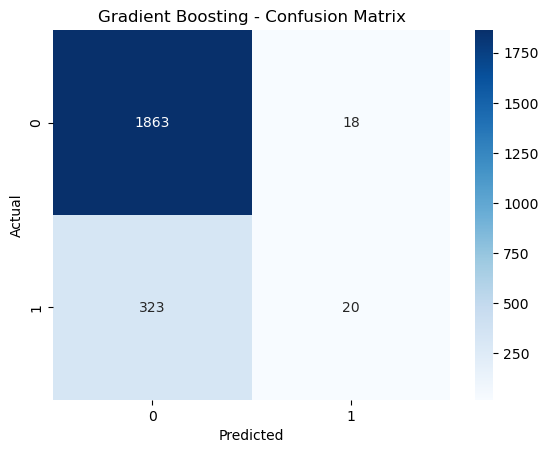

In [240]:
# confusion matrix to analyze prediction errors

cm = confusion_matrix(y_val, y_val_pred_gb)

# Visualize confusion matrix
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Gradient Boosting - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Gradient Boosting (baseline) results

The baseline Gradient Boosting model achieved high overall accuracy, mainly due to correctly predicting the majority class (not buyers).

The recall for the positive class (buyers) is extremely low, meaning that the model is missing most actual customers, this indicates that the model is too conservative and biased towards predicting non-buyers.

From a practical perspective, this is a major limitation, since failing to detect potential buyers reduces the usefulness of the model. This baseline provides a reference point, but requires improvements to better capture the minority class.

---

### **GRADIENT BOOSTING CLASSIFIER MODEL (SMOTE + GRID SEARCH)**

In [241]:
# Apply SMOTE to balance the dataset this creates synthetic samples for the minority class (buyers)

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [242]:
# Initialize Gradient Boosting model
gb_model = GradientBoostingClassifier(random_state=42)

# Define hyperparameter grid for tuning
param_grid = {
    "n_estimators": [100, 200],                  # number of trees
    "learning_rate": [0.05, 0.1],                # how fast the model learns
    "max_depth": [3, 5]                          # complexity of each tree
}

# Perform GridSearch with  3 cross-validation
# Using recall as scoring because detecting buyers is important
grid_search_gb = GridSearchCV(
    gb_model,
    param_grid,
    cv=3,
    scoring="recall",  
    n_jobs=-1,
    verbose=2
)

# Train model on balanced data
grid_search_gb.fit(X_train_smote, y_train_smote)

Fitting 3 folds for each of 8 candidates, totalling 24 fits


,estimator,GradientBoost...ndom_state=42)
,param_grid,"{'learning_rate': [0.05, 0.1], 'max_depth': [3, 5], 'n_estimators': [100, 200]}"
,scoring,'recall'
,n_jobs,-1
,refit,True
,cv,3
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,loss,'log_loss'


In [243]:
# Get best model
best_gb = grid_search_gb.best_estimator_

# Make predictions on validation set
y_val_pred_gb_tuned = best_gb.predict(X_val)

In [244]:
# Evaluate model performance

print(classification_report(y_val, y_val_pred_gb_tuned))          # Print classification metrics (precision, recall, f1-score) 

              precision    recall  f1-score   support

       False       0.87      0.92      0.89      1881
        True       0.37      0.27      0.31       343

    accuracy                           0.82      2224
   macro avg       0.62      0.59      0.60      2224
weighted avg       0.80      0.82      0.80      2224



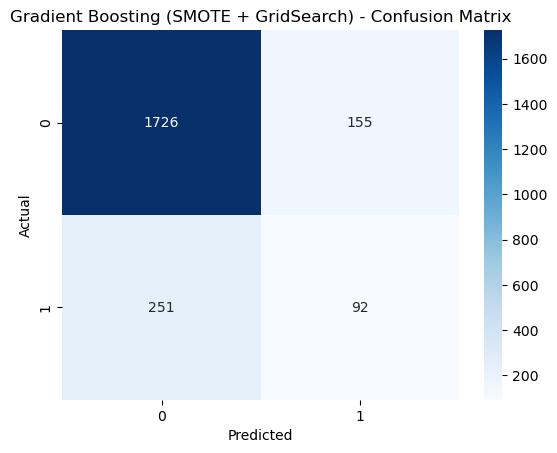

In [245]:
# confusion matrix to analyze prediction errors
cm = confusion_matrix(y_val, y_val_pred_gb_tuned)

# Visualize confusion matrix
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Gradient Boosting (SMOTE + GridSearch) - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Gradient Boosting (SMOTE + GridSearch) results

After applying SMOTE and hyperparameter tuning, the Gradient Boosting model improved its ability to detect buyers.

The recall for the positive class increased compared to the baseline, meaning that the model is now identifying more actual customers. The recall is still relatively low, indicating that many buyers are still not being detected.

This suggests that while the model has improved, it still struggles to fully capture the behavior of the minority class. This version performs better than the baseline, but further adjustments (such as threshold tuning) are needed to make it more effective for the problem.

---

### **THRESHOLD TUNING TO GRADIENT BOOSTING CLASSIFIER MODEL (SMOTE + GRID SEARCH)**

In [246]:
# Set custom threshold, lowering the threshold makes the model more likely to predict buyer

threshold = 0.3

# Get predicted probabilities for the positive class (buyers)
y_val_proba_gb = best_gb.predict_proba(X_val)[:, 1]

# Apply custom threshold to convert probabilities into class predictions
y_val_pred_gb_custom = (y_val_proba_gb >= threshold).astype(int)

In [247]:
# Evaluate model performance after threshold adjustment

print(classification_report(y_val, y_val_pred_gb_custom))

              precision    recall  f1-score   support

       False       0.90      0.80      0.84      1881
        True       0.31      0.51      0.39       343

    accuracy                           0.75      2224
   macro avg       0.61      0.65      0.62      2224
weighted avg       0.81      0.75      0.77      2224



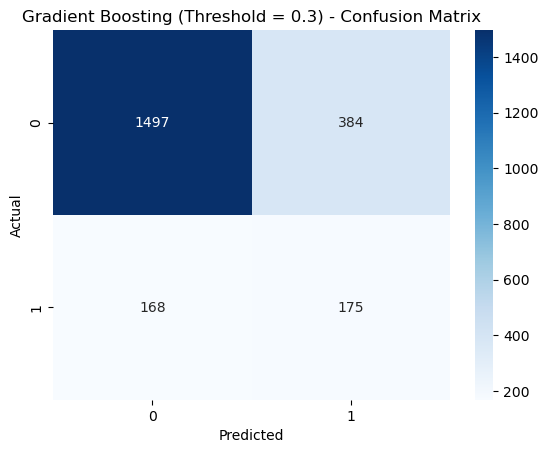

In [248]:
# confusion matrix using custom predictions
cm = confusion_matrix(y_val, y_val_pred_gb_custom)

# Visualize confusion matrix
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Gradient Boosting (Threshold = 0.3) - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Gradient Boosting (SMOTE + GridSearch + threshold) results

After applying threshold tuning, the Gradient Boosting model significantly improved its ability to detect buyers.

The recall for the positive class increased, meaning that more actual customers are now correctly identified. This improvement comes at the cost of lower precision, as more non-buyers are incorrectly classified as buyers.

This trade-off can be acceptable in a real-world scenario where missing potential buyers is more costly than targeting users who may not convert, this version shows a much better balance between precision and recall compared to previous versions of the model.

---

### **ERROR ANALYSIS TO THRESHOLD TUNING GRADIENT BOOSTING CLASSIFIER MODEL (SMOTE + GRID SEARCH)**

In [249]:
# Create a copy of validation data to analyze errors without modifying original data
X_val_analysis_gb = X_val.copy()

# Add actual labels and model predictions
X_val_analysis_gb["actual"] = y_val
X_val_analysis_gb["pred"] = y_val_pred_gb_custom

In [250]:
# False Positives: model predicted buyer but user did not buy
false_positives_gb = X_val_analysis_gb[(X_val_analysis_gb["actual"] == 0) & (X_val_analysis_gb["pred"] == 1)]

# False Negatives: model failed to detect real buyers
false_negatives_gb = X_val_analysis_gb[(X_val_analysis_gb["actual"] == 1) & (X_val_analysis_gb["pred"] == 0)]

In [251]:
# Print number of errors of each type

print("False Positives GB:", len(false_positives_gb))
print("False Negatives GB:", len(false_negatives_gb))

False Positives GB: 384
False Negatives GB: 168


In [252]:
# Analyze which traffic sources generate more false positives

false_positives_gb["TrafficType"].value_counts()

TrafficType
2     192
1      61
3      32
4      27
8      18
10     11
11     10
6       9
20      9
5       8
13      5
14      1
7       1
Name: count, dtype: int64

In [253]:
# Analyze in which months the model fails to detect buyers

false_negatives_gb.filter(like="Month").sum().sort_values(ascending=False)

Month_Nov     47.0
Month_May     32.0
Month_Mar     29.0
Month_Dec     21.0
Month_Oct     14.0
Month_Jul     11.0
Month_June     6.0
Month_Sep      5.0
Month_Feb      0.0
dtype: float64

In [254]:
# Analyze user behavior (ProductRelated) in false negatives

false_negatives_gb["ProductRelated"].describe()

count    168.000000
mean      38.500000
std       41.767535
min        1.000000
25%       14.000000
50%       28.000000
75%       50.000000
max      357.000000
Name: ProductRelated, dtype: float64

A error analysis was performed to understand how the model behaves after threshold tuning.

- The results show that the model still struggles in similar situations as previous models. Most errors are concentrated in specific traffic sources, particularly TrafficType 2, 1 and 3.

- In addition, the model continues to miss buyers in certain months such as November, May and March, suggesting that it does not fully capture seasonal behavior.

- The analysis of ProductRelated also shows that some users with relatively high interaction are still not detected as buyers, indicating that the model has difficulty distinguishing real purchase intent.

While the model improved recall after threshold tuning, the same error patterns persist. This suggests that the limitation is not only related to the model, but also to the available features and the nature of the dataset.

---

## **MODEL COMPARISON**

In [255]:
# Store results from all models in a list

results = []

# Logistic Regression (baseline)
results.append({
    "Model": "Logistic Regression model  (with class balancing)",
    "Recall": recall_score(y_val, y_val_pred_log),
    "Precision": precision_score(y_val, y_val_pred_log),
    "F1": f1_score(y_val, y_val_pred_log),
    "Accuracy": accuracy_score(y_val, y_val_pred_log)
})

# Logistic Regression (with threshold tuning)
results.append({
    "Model": "Logistic Regression model (threshold)",
    "Recall": recall_score(y_val, y_val_pred_custom_log),
    "Precision": precision_score(y_val, y_val_pred_custom_log),
    "F1": f1_score(y_val, y_val_pred_custom_log),
    "Accuracy": accuracy_score(y_val, y_val_pred_custom_log)
})

# Random Forest (baseline)
results.append({
    "Model": "Random Forest model (with class balancing)",
    "Recall": recall_score(y_val, y_val_pred_rf_base),
    "Precision": precision_score(y_val, y_val_pred_rf_base),
    "F1": f1_score(y_val, y_val_pred_rf_base),
    "Accuracy": accuracy_score(y_val, y_val_pred_rf_base)
})

# Random Forest (tuned with GridSearch)
results.append({
    "Model": "Random Forest model tuned",
    "Recall": recall_score(y_val, y_val_pred_rf),
    "Precision": precision_score(y_val, y_val_pred_rf),
    "F1": f1_score(y_val, y_val_pred_rf),
    "Accuracy": accuracy_score(y_val, y_val_pred_rf)
})

# Random Forest (tuned + threshold)
results.append({
    "Model": "Random Forest model (tuned + threshold)",
    "Recall": recall_score(y_val, y_val_pred_custom_rf),
    "Precision": precision_score(y_val, y_val_pred_custom_rf),
    "F1": f1_score(y_val, y_val_pred_custom_rf),
    "Accuracy": accuracy_score(y_val, y_val_pred_custom_rf)
})

# Gradient Boosting baseline
results.append({
    "Model": "Gradient Boosting (baseline)",
    "Recall": recall_score(y_val, y_val_pred_gb),
    "Precision": precision_score(y_val, y_val_pred_gb),
    "F1": f1_score(y_val, y_val_pred_gb),
    "Accuracy": accuracy_score(y_val, y_val_pred_gb)
})

# Gradient Boosting tuned (SMOTE + GridSearch)
results.append({
    "Model": "Gradient Boosting (tuned)",
    "Recall": recall_score(y_val, y_val_pred_gb_tuned),
    "Precision": precision_score(y_val, y_val_pred_gb_tuned),
    "F1": f1_score(y_val, y_val_pred_gb_tuned),
    "Accuracy": accuracy_score(y_val, y_val_pred_gb_tuned)
})

# Gradient Boosting threshold
results.append({
    "Model": "Gradient Boosting (tuned + threshold)",
    "Recall": recall_score(y_val, y_val_pred_gb_custom),
    "Precision": precision_score(y_val, y_val_pred_gb_custom),
    "F1": f1_score(y_val, y_val_pred_gb_custom),
    "Accuracy": accuracy_score(y_val, y_val_pred_gb_custom)
})

# Convert results into a DataFrame for comparison
df_results = pd.DataFrame(results)

# Sort by Recall (most important metric here)
df_results.sort_values(by="Recall", ascending=False).round(3).reset_index(drop=True)

,Model,Recall,Precision,F1,Accuracy
0,Logistic Regression model (with class balancing),0.755,0.266,0.394,0.642
1,Logistic Regression model (threshold),0.586,0.295,0.392,0.720
2,Random Forest model (tuned + threshold),0.571,0.306,0.398,0.734
3,Gradient Boosting (tuned + threshold),0.510,0.313,0.388,0.752
4,Gradient Boosting (tuned),0.268,0.372,0.312,0.817
5,Random Forest model tuned,0.227,0.377,0.284,0.823
6,Gradient Boosting (baseline),0.058,0.526,0.105,0.847
7,Random Forest model (with class balancing),0.050,0.370,0.087,0.840


After comparing all the models, I can see clear differences in how they behave.

- The Logistic Regression baseline achieved the highest recall, which means it detects most of the buyers. However, its precision is very low, so it makes many incorrect predictions by classifying non-buyers as buyers.

- The Gradient Boosting model shows better precision, but its recall is lower, meaning it misses many real buyers.

- The Random Forest model with tuning and threshold adjustment provides the best balance between recall and precision. It still detects a good number of buyers, but with fewer mistakes compared to Logistic Regression.

For this reason, I consider the Random Forest (tuned + threshold) model as the best option, since it offers a more realistic and balanced performance for this problem.

---

### **Real-Time Prediction Simulation and Business Decision**

This simulates how the final model can be used in a real-time scenario.

A single user session is taken as input, and the model predicts the probability of that user making a purchase. 
Instead of directly using the default threshold (0.5), a custom threshold of 0.3 is applied to increase the model's sensitivity.

Based on this probability, a business decision is made immediately:
- High probability users receive a strong discount
- Medium probability users receive a small incentive
- Low probability users receive no action

This approach reflects how companies can use machine learning models in practice to improve conversion rates by reacting to user behavior in real time.

In [256]:
def real_time_decision(model, user_data, threshold):
    # Convert input to DataFrame
    user_df = pd.DataFrame([user_data])

    # Predict probability
    prob = model.predict_proba(user_df)[:, 1][0]

    # Apply threshold
    prediction = 1 if prob >= threshold else 0

    # Business decision
    if prob >= 0.7:
        action = "High-value user - strong discount"
    elif prob >= threshold:
        action = "Medium probability - small incentive"
    else:
        action = "Low probability - no action"

    return prob, prediction, action

In [257]:
final_model = best_rf
final_threshold = 0.3

# Select one user
user_example = X_val.iloc[1000].to_dict()

# Apply final model
prob, pred, action = real_time_decision(
    final_model,
    user_example,
    final_threshold
)

print("Probability:", round(prob, 3))
print("Prediction:", pred)
print("Action:", action)

Probability: 0.32
Prediction: 1
Action: Medium probability - small incentive


In this example, the selected user has a moderate probability of making a purchase (32%). Based on this prediction, a small incentive is offered to encourage the user to complete the purchase.

This simulation demonstrates how the model can support real-time decision-making. In a real-world system, these predictions would need to be generated very quickly to be useful while the user is still browsing the website.

---

## **Final Model Evaluation on Test Set**

In [258]:
# Combine training and validation data (both already preprocessed)
# This allows the model to learn from as much data as possible before final evaluation

X_train_val_final = pd.concat([X_train, X_val]).reset_index(drop=True)
y_train_val_final = pd.concat([y_train, y_val]).reset_index(drop=True)

# Define final decision threshold (chosen during validation phase)
final_threshold = 0.3

# Select the best model (Random Forest with tuning and threshold)
final_model = best_rf

# Train the final model on the full training + validation data
final_model.fit(X_train_val_final, y_train_val_final)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [259]:
# Get predicted probabilities for the positive class 
y_test_proba = final_model.predict_proba(X_test)[:, 1]

# Apply the chosen threshold to convert probabilities into class predictions
y_test_pred = (y_test_proba >= final_threshold).astype(int)

In [260]:
# FINAL EVALUATION
print("FINAL TEST RESULTS\n")
print(classification_report(y_test, y_test_pred))                # Print classification metrics: precision, recall, F1-score

FINAL TEST RESULTS

              precision    recall  f1-score   support

       False       0.89      0.86      0.87      1880
        True       0.35      0.40      0.37       344

    accuracy                           0.79      2224
   macro avg       0.62      0.63      0.62      2224
weighted avg       0.80      0.79      0.80      2224



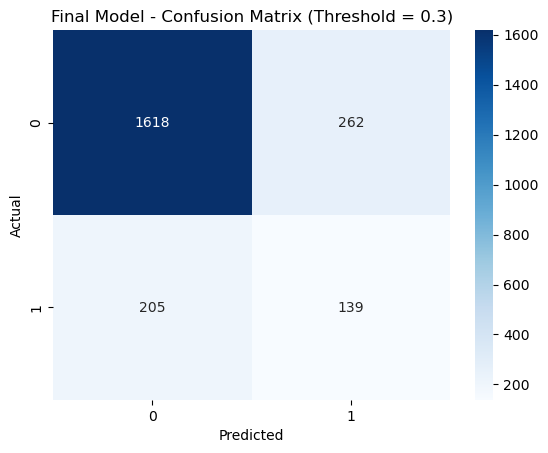

In [261]:
# confusion matrix to visualize model performance
cm = confusion_matrix(y_test, y_test_pred)

# Plot confusion matrix
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title(f"Final Model - Confusion Matrix (Threshold = {final_threshold})")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Analysis on final evaluation

In the final test evaluation, the model shows a reasonable but not perfect performance.

It is able to correctly identify some of the users who will make a purchase, but it still misses a significant number of real buyers, as shown by the recall of around 0.40. This means that more than half of the potential buyers are not detected. At the same time, the precision is relatively low, which indicates that some users are incorrectly predicted as buyers. This can lead to unnecessary marketing actions.

The model achieves a good balance between detecting buyers and avoiding too many false positives. From a business perspective, this trade-off can still be useful in real-time decision-making scenarios.

**Since the test set was only used once for final evaluation, these results can be considered a realistic estimate of how the model would perform in a real-world scenario.**

---

## **Final Conclusions**

The objective of this project was to build a machine learning model capable of predicting whether a user will make a purchase during a session, with the goal of supporting real-time decision making in an e-commerce environment.

After exploring the data, training different models, and comparing their performance, the final selected model was a **Random Forest classifier with hyperparameter tuning and threshold adjustment**.

- The final model was trained using optimized hyperparameters obtained through GridSearchCV, including parameters such as the number of trees, maximum depth, and minimum samples per split. To deal with the imbalance in the dataset, SMOTE was applied to the training data so the model could better learn from the minority class. In addition, a custom decision threshold of 0.3 was used to improve the detection of potential buyers. These steps helped the model handle the imbalance more effectively and focus on identifying users who are more likely to make a purchase, which is more aligned with the business objective.

- From a technical perspective, the model achieves a reasonable balance between detecting buyers and avoiding too many incorrect predictions. However, the results show that there is still a trade-off between recall and precision. The model is able to identify some real buyers, but it also misses a significant portion of them.

- From a business point of view, this means that the model can be used to support decision making in real time, but it should be applied depending on the company's priorities. For example, if the goal is to capture more potential buyers, the threshold could be adjusted to increase recall, even if this leads to more false positives.

One important insight from the analysis is that user behavior features, such as product related activity and session characteristics, play a key role in predicting purchase intent. Additionally, the error analysis showed that the model tends to struggle in certain situations, such as specific months or user segments, which could be explored further.

The real time simulation demonstrates how this model could be integrated into a live system. For example, users with a high predicted probability could receive targeted offers, while low probability users may not require any action. This shows the practical value of the model beyond just prediction.

This project highlights how machine learning can be used to improve user experience and business performance in e-commerce. At the same time, it also shows the importance of understanding model limitations and making decisions based on both technical performance and business goals.